<a href="https://colab.research.google.com/github/contreras-juan/Material-Ciencia-de-Datos/blob/main/Deep_Learning/Ejercicios/Soluciones/04_Taller_Autoencoders_Solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<h1 style="color: #FECB05; text-align: center;">Solución — Taller práctico: Autoencoders</h1>


<h2 style="color: #007ACC;">Autores</h2>

- [Juan Felipe Contreras Alcívar](https://www.linkedin.com/in/juanf-contreras/)

> Solución de referencia de [`04_Taller_Autoencoders.ipynb`](../04_Taller_Autoencoders.ipynb).
> Los resultados pueden variar ligeramente según TensorFlow/hardware.


---


<h2 style="color: #007ACC;">Tabla de contenido</h2>

- [Instalación e importaciones](#importaciones)
- [Ejercicio 1](#ejercicio-1)
- [Ejercicio 2](#ejercicio-2)
- [Ejercicio 3](#ejercicio-3)
- [Ejercicio 4](#ejercicio-4)
- [Ejercicio 5](#ejercicio-5)
- [Ejercicio 6](#ejercicio-6)
- [Ejercicio 7](#ejercicio-7)
- [Ejercicio integrador](#ejercicio-integrador)


---

<a id="importaciones"></a>
<h2 style="color: #007ACC;">Instalación e importaciones</h2>


In [1]:
# Instalación de librerías necesarias para esta sesión
# (útil en Google Colab o en un entorno nuevo)
%pip install -q numpy pandas matplotlib scikit-learn tensorflow


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import (
    Conv2D,
    Conv2DTranspose,
    Dense,
    Input,
    MaxPooling2D,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

def plot_history(history, title="Curvas de entrenamiento"):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, hist["loss"], label="train loss")
    if "val_loss" in hist:
        plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def show_images(rows, titles, n=10, h=28, w=28, cmap="gray"):
    """Una fila por arreglo; `n` columnas."""
    n_rows = len(rows)
    plt.figure(figsize=(20, 2.2 * n_rows))
    for r, (imgs, title) in enumerate(zip(rows, titles)):
        for i in range(n):
            ax = plt.subplot(n_rows, n, r * n + i + 1)
            plt.imshow(np.asarray(imgs[i]).reshape(h, w), cmap=cmap)
            if i == 0:
                ax.set_ylabel(title, fontsize=11)
            plt.xticks([])
            plt.yticks([])
    plt.tight_layout()
    plt.show()


FASHION_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def reconstruction_mse(x_true, x_hat):
    x_true = np.asarray(x_true, dtype="float32").reshape(len(x_true), -1)
    x_hat = np.asarray(x_hat, dtype="float32").reshape(len(x_hat), -1)
    return np.mean(np.square(x_true - x_hat), axis=1)


def es_callbacks(patience=3):
    return [
        EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]


def build_dense_ae(input_dim, latent_dim, hidden=128, out_activation="sigmoid"):
    inp = Input(shape=(input_dim,), name="entrada")
    h = Dense(hidden, activation="relu", name="enc_1")(inp)
    z = Dense(latent_dim, activation="linear", name="latente")(h)
    h = Dense(hidden, activation="relu", name="dec_1")(z)
    out = Dense(input_dim, activation=out_activation, name="reconstruccion")(h)
    ae = Model(inp, out, name="autoencoder")
    encoder = Model(inp, z, name="encoder")
    ae.compile(optimizer="adam", loss="mse")
    return ae, encoder


I0000 00:00:1786748368.437260   40781 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786748368.437568   40781 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786748368.459804   40781 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0


I0000 00:00:1786748369.017213   40781 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786748369.017383   40781 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


---

<a id="ejercicio-1"></a>
<h2 style="color: #007ACC;">Ejercicio 1. Formas y pérdida de reconstrucción</h2>


In [3]:
def linear_bottleneck(X, k):
    X = np.asarray(X, dtype="float32")
    mu = X.mean(axis=0, keepdims=True)
    Xc = X - mu
    _, _, vt = np.linalg.svd(Xc, full_matrices=False)
    W = vt[:k]
    return (Xc @ W.T) @ W + mu


x = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]], dtype="float32")
x_hat = np.array([[1.0, 0.0, 0.0], [1.0, 1.0, 0.0]], dtype="float32")
err = reconstruction_mse(x, x)
err2 = reconstruction_mse(x, x_hat)
print("MSE identidad (media):", float(err.mean()))
print("Errores ejemplo:", err2)

rng = np.random.default_rng(SEED)
X = rng.normal(size=(20, 6)).astype("float32")
rec2 = linear_bottleneck(X, 2)
rec6 = linear_bottleneck(X, 6)
print("MSE k=2:", float(reconstruction_mse(X, rec2).mean()))
print("MSE k=6:", float(reconstruction_mse(X, rec6).mean()))
print(
    "Si dim(z)=dim(x) y las capas son lineales, el AE puede aprender la identidad "
    "(reconstrucción perfecta sin comprimir). El cuello de botella o el ruido "
    "obligan a extraer estructura; un AE lineal undercomplete reproduce PCA."
)


MSE identidad (media): 0.0
Errores ejemplo: [0.         0.33333334]
MSE k=2: 0.21109013259410858
MSE k=6: 4.5998505365471044e-15
Si dim(z)=dim(x) y las capas son lineales, el AE puede aprender la identidad (reconstrucción perfecta sin comprimir). El cuello de botella o el ruido obligan a extraer estructura; un AE lineal undercomplete reproduce PCA.


---

<a id="ejercicio-2"></a>
<h2 style="color: #007ACC;">Ejercicio 2. Cacería de leakage</h2>


E0000 00:00:1786748369.137008   40781 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1786748369.137225   40860 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1786748369.157021   40781 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Errores del pipeline incorrecto:
(1) MinMaxScaler.fit sobre normales+anómalos: el rango lo marcan los outliers.
(2) train_test_split aleatorio mezcla anomalías en el train: el AE aprende a reconstruirlas.
(3) Percentil 95 del error en un test ya mezclado usa las anomalías para fijar el umbral.


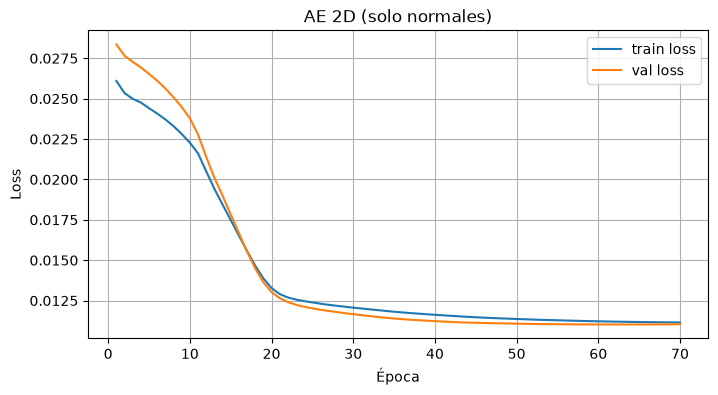

Umbral (p95 val normal): 0.0404
FPR test normales: 10.8%
TPR test anomalías: 100.0%


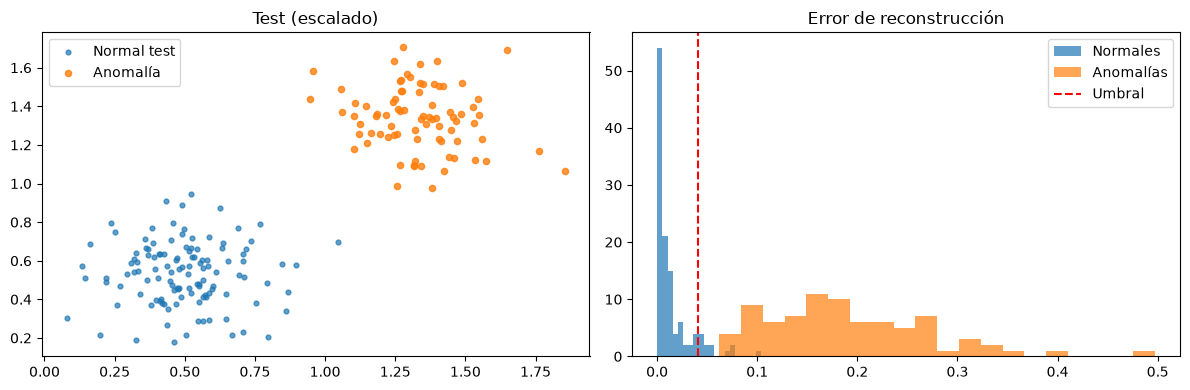

In [4]:
print("Errores del pipeline incorrecto:")
print("(1) MinMaxScaler.fit sobre normales+anómalos: el rango lo marcan los outliers.")
print("(2) train_test_split aleatorio mezcla anomalías en el train: el AE aprende a reconstruirlas.")
print("(3) Percentil 95 del error en un test ya mezclado usa las anomalías para fijar el umbral.")

rng = np.random.default_rng(SEED)
normales = rng.normal(0, 1, size=(800, 2)).astype("float32")
anomalos = rng.normal(5, 1, size=(80, 2)).astype("float32")

n_tr, n_tmp = train_test_split(normales, test_size=0.3, random_state=SEED)
n_va, n_te = train_test_split(n_tmp, test_size=0.5, random_state=SEED)
a_te = anomalos  # todas las anomalías van a evaluación

scaler_2d = MinMaxScaler()
n_tr_s = scaler_2d.fit_transform(n_tr)
n_va_s = scaler_2d.transform(n_va)
n_te_s = scaler_2d.transform(n_te)
a_te_s = scaler_2d.transform(a_te)

ae_2d, _ = build_dense_ae(2, latent_dim=1, hidden=8, out_activation="sigmoid")
hist_2d = ae_2d.fit(
    n_tr_s,
    n_tr_s,
    validation_data=(n_va_s, n_va_s),
    epochs=80,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=0,
)
plot_history(hist_2d, "AE 2D (solo normales)")

thr = np.percentile(reconstruction_mse(n_va_s, ae_2d.predict(n_va_s, verbose=0)), 95)
err_n = reconstruction_mse(n_te_s, ae_2d.predict(n_te_s, verbose=0))
err_a = reconstruction_mse(a_te_s, ae_2d.predict(a_te_s, verbose=0))
print(f"Umbral (p95 val normal): {thr:.4f}")
print(f"FPR test normales: {np.mean(err_n > thr):.1%}")
print(f"TPR test anomalías: {np.mean(err_a > thr):.1%}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(n_te_s[:, 0], n_te_s[:, 1], s=12, alpha=0.7, label="Normal test")
plt.scatter(a_te_s[:, 0], a_te_s[:, 1], s=20, alpha=0.8, label="Anomalía")
plt.title("Test (escalado)")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(err_n, bins=20, alpha=0.7, label="Normales")
plt.hist(err_a, bins=20, alpha=0.7, label="Anomalías")
plt.axvline(thr, color="red", linestyle="--", label="Umbral")
plt.title("Error de reconstrucción")
plt.legend()
plt.tight_layout()
plt.show()


---

<a id="ejercicio-3"></a>
<h2 style="color: #007ACC;">Ejercicio 3. Autoencoder denso en Fashion-MNIST</h2>


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 784) | Test: (10000, 784)
Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0499 - val_loss: 0.0272 - learning_rate: 0.0010
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0239 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0209 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0196 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0188 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0183 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0179 - val_loss: 0.0180 - learning_rate: 0.0010
E

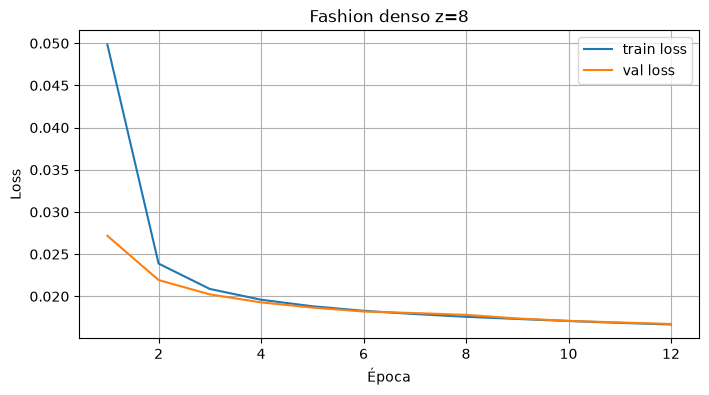

latent_dim=8 | MSE test=0.01667 | params=203800


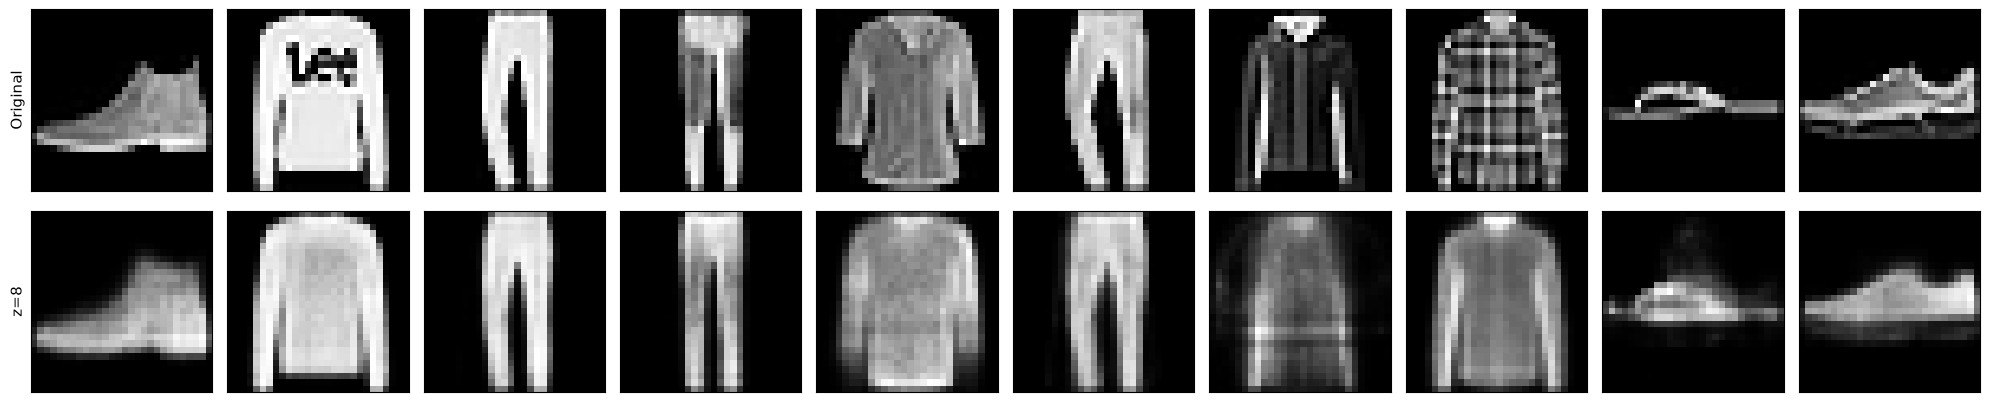

Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0426 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0195 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0165 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0149 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0138 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0130 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0124 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 8/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0119 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 9/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0114 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 10/1

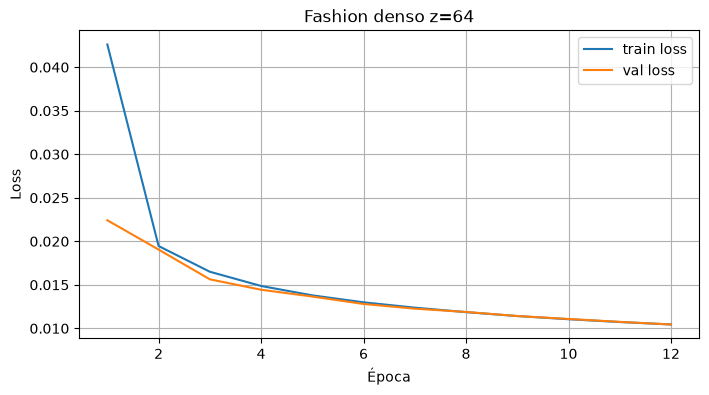

latent_dim=64 | MSE test=0.01046 | params=218192


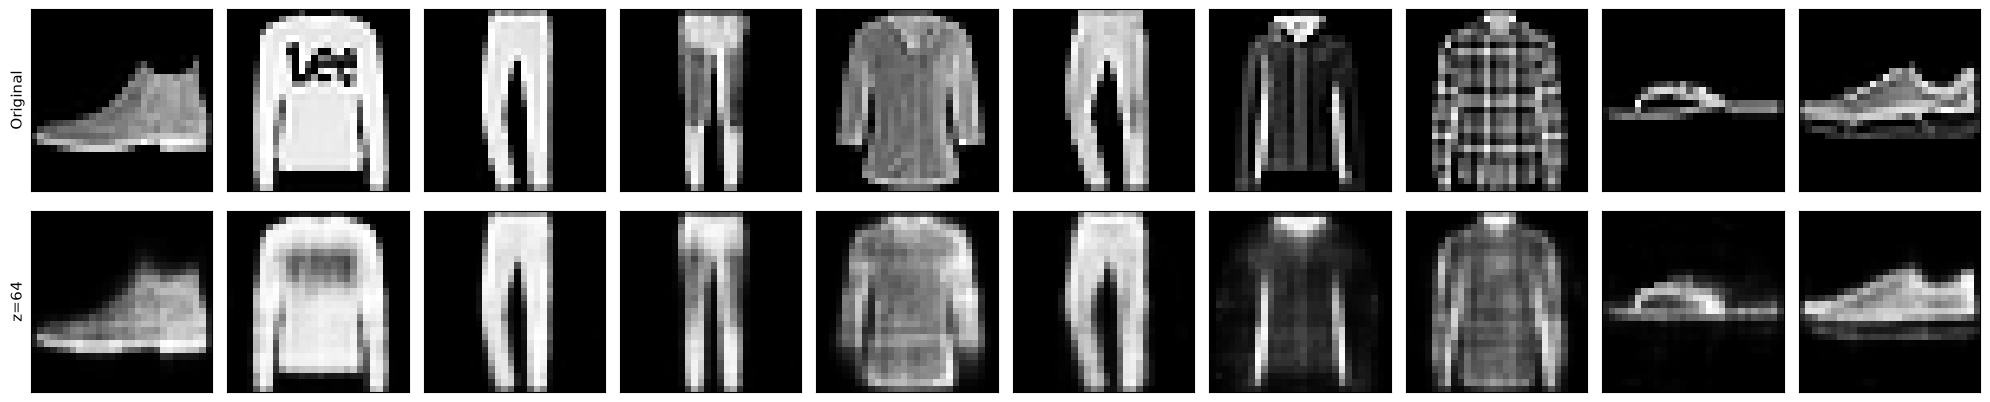

Menor MSE no implica mejor representación: z=64 puede acercarse a copiar píxeles. z=8 comprime más (útil para anomalías o un clasificador lineal) a costa de desenfoque.


In [5]:
(x_train_img, y_train), (x_test_img, y_test) = fashion_mnist.load_data()
x_train_img = x_train_img.astype("float32") / 255.0
x_test_img = x_test_img.astype("float32") / 255.0
x_train = x_train_img.reshape(len(x_train_img), -1)
x_test = x_test_img.reshape(len(x_test_img), -1)
print("Train:", x_train.shape, "| Test:", x_test.shape)

dense_models = {}
for k in (8, 64):
    tf.random.set_seed(SEED)
    ae, enc = build_dense_ae(784, latent_dim=k, hidden=128)
    hist = ae.fit(
        x_train,
        x_train,
        epochs=12,
        batch_size=256,
        validation_split=0.1,
        callbacks=es_callbacks(3),
        verbose=1,
    )
    plot_history(hist, f"Fashion denso z={k}")
    mse = float(ae.evaluate(x_test, x_test, verbose=0))
    x_hat = ae.predict(x_test, verbose=0)
    print(f"latent_dim={k} | MSE test={mse:.5f} | params={ae.count_params()}")
    show_images([x_test, x_hat], ["Original", f"z={k}"])
    dense_models[k] = {"ae": ae, "encoder": enc, "mse": mse, "hist": hist}

print(
    "Menor MSE no implica mejor representación: z=64 puede acercarse a copiar píxeles. "
    "z=8 comprime más (útil para anomalías o un clasificador lineal) a costa de desenfoque."
)


---

<a id="ejercicio-4"></a>
<h2 style="color: #007ACC;">Ejercicio 4. Denoising sal y pimienta</h2>


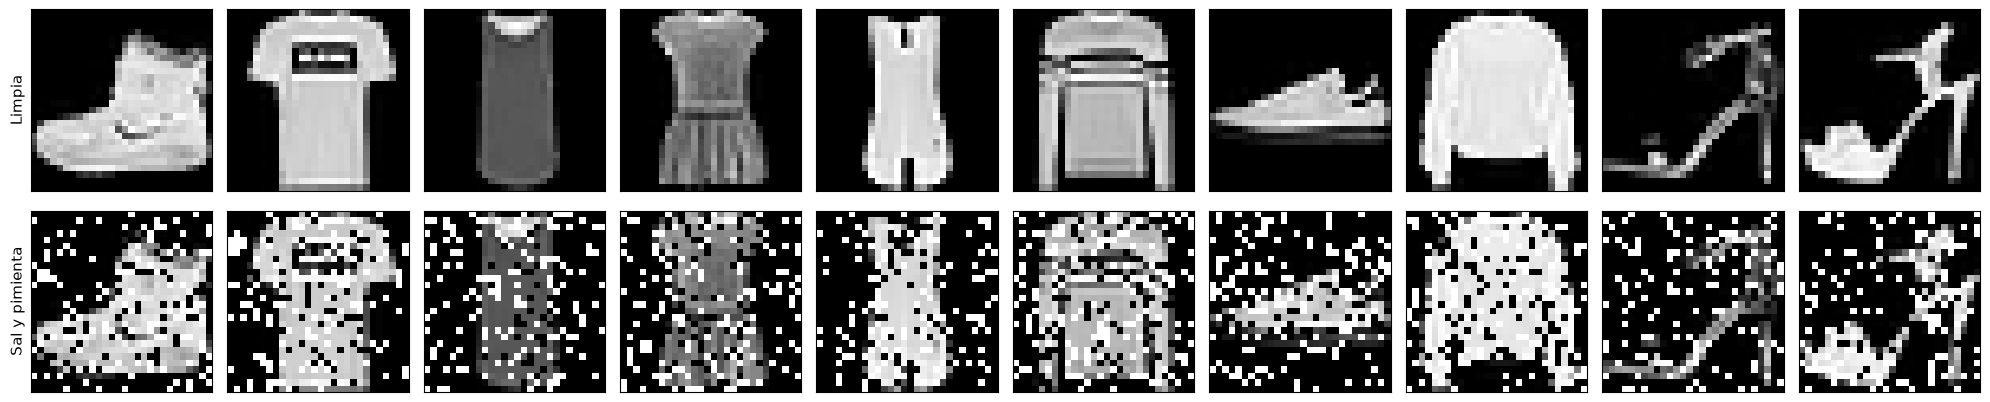

Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0502 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0265 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0233 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0218 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0209 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0200 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0193 - val_loss: 0.0195 - learning_rate: 0.0010
Epoch 8/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0187 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 9/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0183 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 10/1

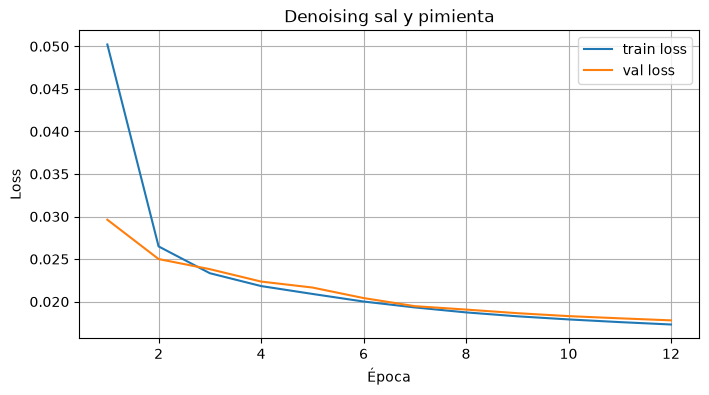

MSE test (limpia vs reconstruida): 0.017726797610521317


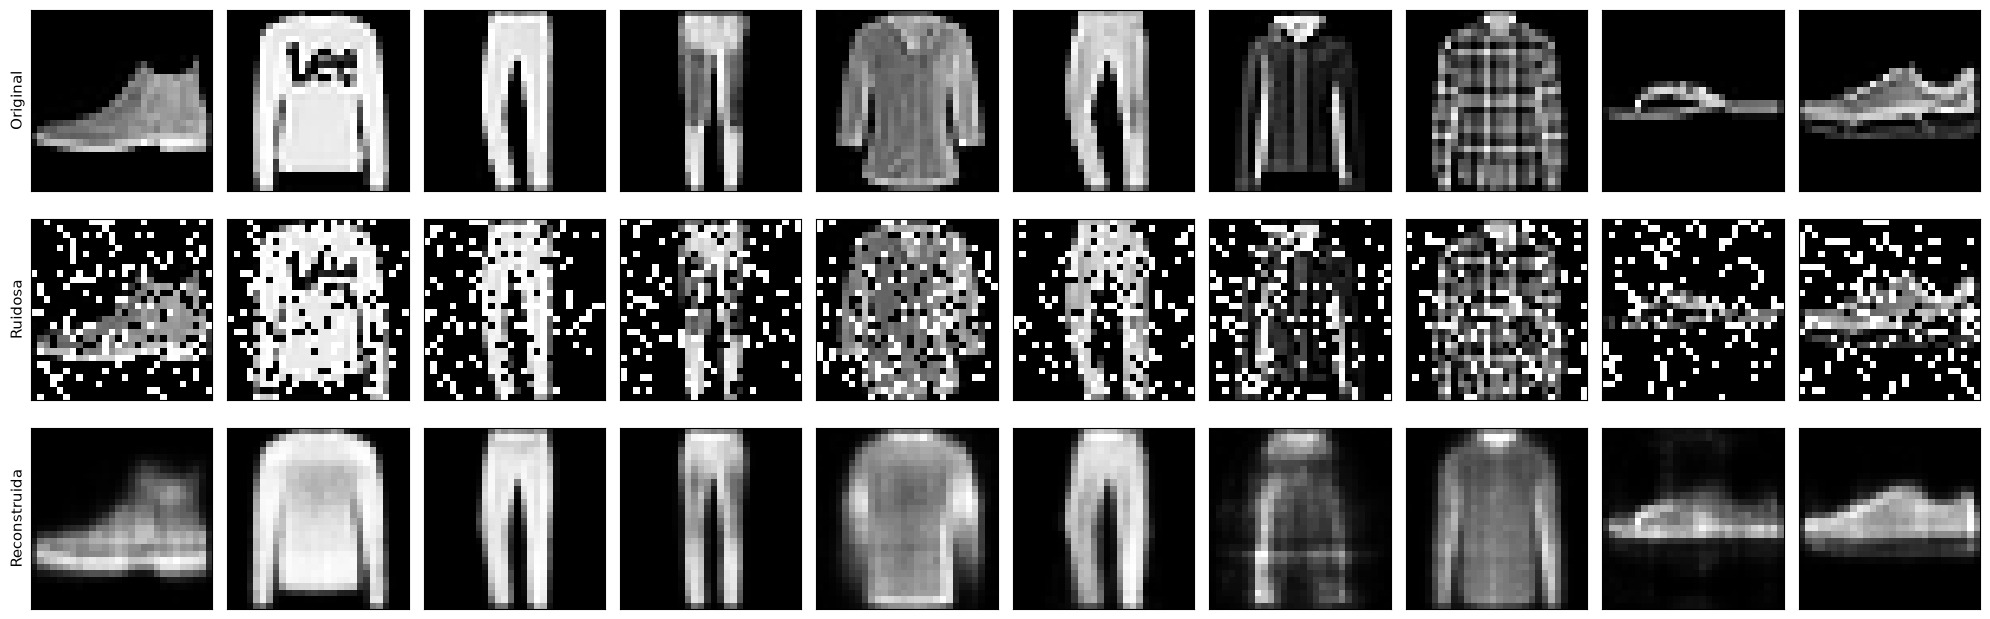

Cada píxel puede estar completamente invertido; copiar la entrada no reduce el MSE respecto a la imagen limpia. La red tiene que inferir la prenda a partir del contexto.


In [6]:
def salt_pepper(X, p=0.3, rng=None):
    rng = np.random.default_rng(SEED) if rng is None else rng
    X = np.asarray(X, dtype="float32").copy()
    u = rng.random(X.shape)
    X[u < p / 2] = 0.0
    X[(u >= p / 2) & (u < p)] = 1.0
    return X


rng_sp = np.random.default_rng(SEED)
x_train_sp = salt_pepper(x_train, p=0.3, rng=rng_sp)
x_test_sp = salt_pepper(x_test, p=0.3, rng=rng_sp)
show_images([x_train, x_train_sp], ["Limpia", "Sal y pimienta"])

tf.random.set_seed(SEED)
denoiser, _ = build_dense_ae(784, latent_dim=32, hidden=128)
hist_dn = denoiser.fit(
    x_train_sp,
    x_train,
    epochs=12,
    batch_size=256,
    validation_split=0.1,
    callbacks=es_callbacks(3),
    verbose=1,
)
plot_history(hist_dn, "Denoising sal y pimienta")
x_den = denoiser.predict(x_test_sp, verbose=0)
print("MSE test (limpia vs reconstruida):", float(reconstruction_mse(x_test, x_den).mean()))
show_images([x_test, x_test_sp, x_den], ["Original", "Ruidosa", "Reconstruida"])
print(
    "Cada píxel puede estar completamente invertido; copiar la entrada no reduce el MSE "
    "respecto a la imagen limpia. La red tiene que inferir la prenda a partir del contexto."
)


---

<a id="ejercicio-5"></a>
<h2 style="color: #007ACC;">Ejercicio 5. Anomalías en ECG</h2>


ECG: (4998, 140) | normales: 0.5840336134453782
Epoch 1/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0232 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0131 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0091 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 4/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0076 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 0.0067 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 6/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0062 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 7/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - loss: 0.0056 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 8/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step - loss: 0.0049 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 9/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - val_loss: 0.005

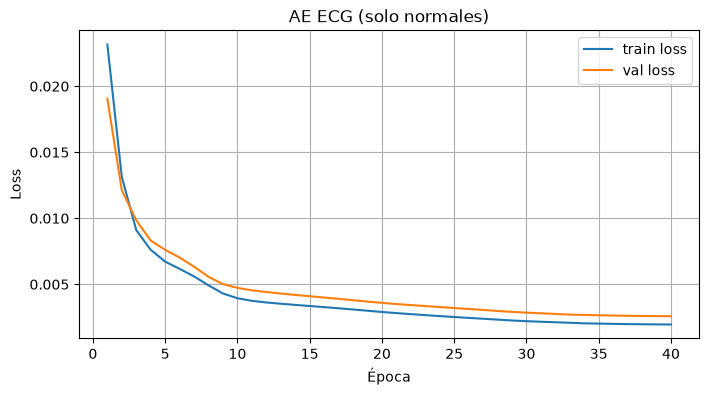

Umbral p95 val: 0.00531
FPR normales test: 5.3%
TPR anómalos test: 99.8%
AUC (error vs anómalo): 0.992


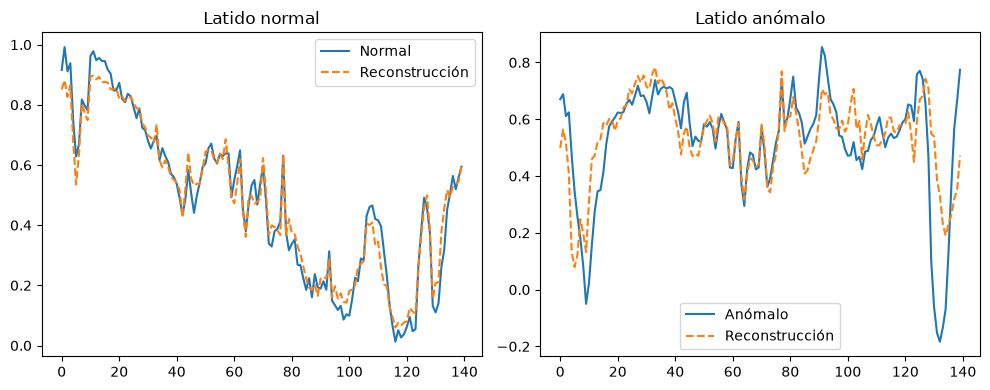

In [7]:
ECG_URL = "https://storage.googleapis.com/download.tensorflow.org/data/ecg.csv"
ecg = pd.read_csv(ECG_URL, header=None)
X_ecg = ecg.iloc[:, :-1].values.astype("float32")
y_ecg = ecg.iloc[:, -1].values.astype(int)  # 1 = normal, 0 = anómalo
print("ECG:", X_ecg.shape, "| normales:", (y_ecg == 1).mean())

X_tr, X_te, y_tr, y_te = train_test_split(
    X_ecg, y_ecg, test_size=0.2, random_state=SEED, stratify=y_ecg
)
X_n = X_tr[y_tr == 1]
X_n_fit, X_n_val = train_test_split(X_n, test_size=0.1, random_state=SEED)

scaler_ecg = MinMaxScaler()
X_n_fit_s = scaler_ecg.fit_transform(X_n_fit)
X_n_val_s = scaler_ecg.transform(X_n_val)
X_te_s = scaler_ecg.transform(X_te)

tf.random.set_seed(SEED)
ae_ecg, _ = build_dense_ae(X_ecg.shape[1], latent_dim=8, hidden=32, out_activation="sigmoid")
hist_ecg = ae_ecg.fit(
    X_n_fit_s,
    X_n_fit_s,
    validation_data=(X_n_val_s, X_n_val_s),
    epochs=40,
    batch_size=64,
    callbacks=es_callbacks(5),
    verbose=1,
)
plot_history(hist_ecg, "AE ECG (solo normales)")

thr_ecg = np.percentile(
    reconstruction_mse(X_n_val_s, ae_ecg.predict(X_n_val_s, verbose=0)), 95
)
err_te = reconstruction_mse(X_te_s, ae_ecg.predict(X_te_s, verbose=0))
pred = err_te > thr_ecg
y_anom = (y_te == 0).astype(int)
print(f"Umbral p95 val: {thr_ecg:.5f}")
print(f"FPR normales test: {pred[y_te == 1].mean():.1%}")
print(f"TPR anómalos test: {pred[y_te == 0].mean():.1%}")
print(f"AUC (error vs anómalo): {roc_auc_score(y_anom, err_te):.3f}")

hat_te = ae_ecg.predict(X_te_s, verbose=0)
i_n = np.where(y_te == 1)[0][0]
i_a = np.where(y_te == 0)[0][0]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(X_te_s[i_n], label="Normal")
plt.plot(hat_te[i_n], "--", label="Reconstrucción")
plt.title("Latido normal")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(X_te_s[i_a], label="Anómalo")
plt.plot(hat_te[i_a], "--", label="Reconstrucción")
plt.title("Latido anómalo")
plt.legend()
plt.tight_layout()
plt.show()


---

<a id="ejercicio-6"></a>
<h2 style="color: #007ACC;">Ejercicio 6. Autoencoder convolucional</h2>


Model: "conv_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0577 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 2/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0147 - val_loss: 0.0137 - learning_rate: 0.0010
Epoch 3/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0131 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 4/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0122 - val_loss: 0.0119 - learning_rate: 0.0010
Epoch 5/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0116 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 6/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 7/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0109 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 8/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0106 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 9/12
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0104 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 10/1

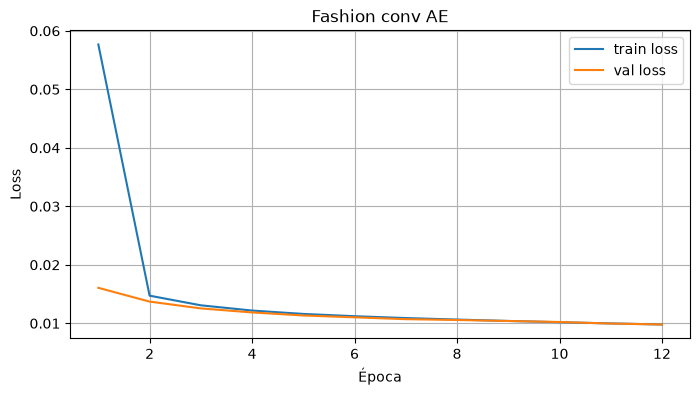

MSE test denso (mejor): 0.01046
MSE test conv:          0.00991


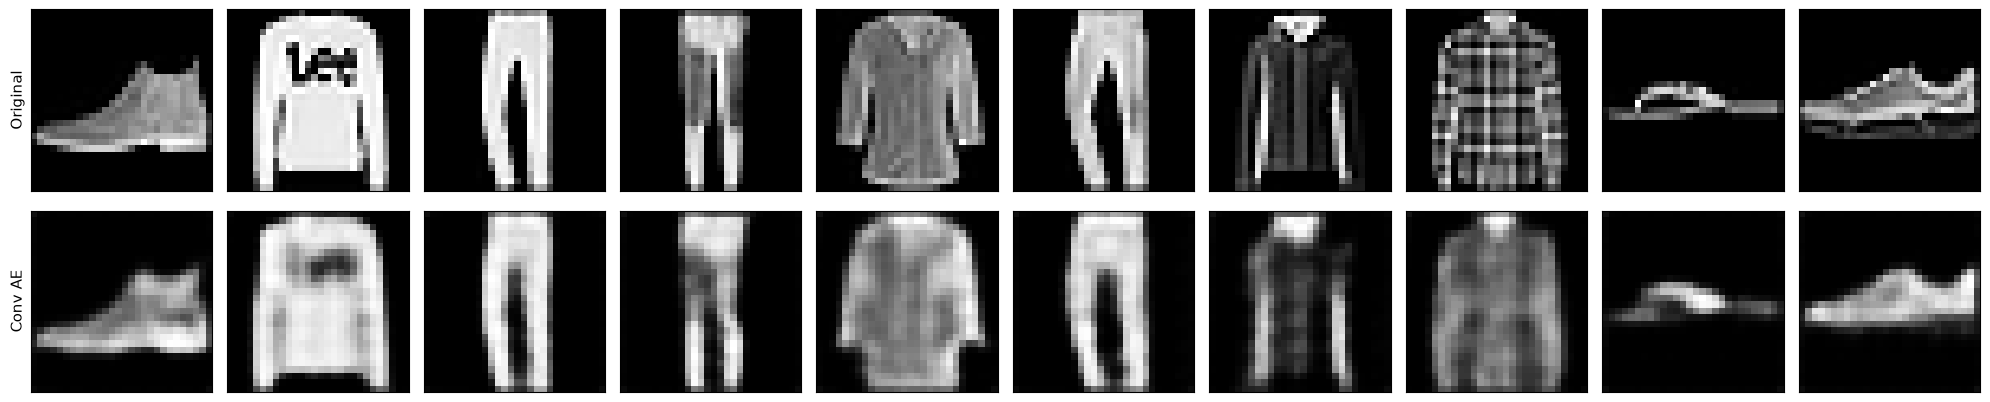

En 28x28 gris el denso ya es competitivo. El conv gana cuando hay más resolución, color o textura (caras, CIFAR, fotos): aplanar destruye vecindad.


In [8]:
x_train_c = x_train_img[..., np.newaxis]
x_test_c = x_test_img[..., np.newaxis]

inp_c = Input(shape=(28, 28, 1))
h = Conv2D(16, 3, activation="relu", padding="same")(inp_c)
h = MaxPooling2D(2, padding="same")(h)
h = Conv2D(8, 3, activation="relu", padding="same")(h)
z_c = MaxPooling2D(2, padding="same")(h)
h = Conv2DTranspose(8, 3, strides=2, activation="relu", padding="same")(z_c)
h = Conv2DTranspose(16, 3, strides=2, activation="relu", padding="same")(h)
out_c = Conv2D(1, 3, activation="sigmoid", padding="same")(h)
conv_ae = Model(inp_c, out_c, name="conv_ae")
conv_ae.compile(optimizer="adam", loss="mse")
conv_ae.summary()

tf.random.set_seed(SEED)
hist_c = conv_ae.fit(
    x_train_c,
    x_train_c,
    epochs=12,
    batch_size=256,
    validation_split=0.1,
    callbacks=es_callbacks(3),
    verbose=1,
)
plot_history(hist_c, "Fashion conv AE")
x_hat_c = conv_ae.predict(x_test_c, verbose=0)
mse_conv = float(conv_ae.evaluate(x_test_c, x_test_c, verbose=0))
best_dense = min(dense_models[k]["mse"] for k in dense_models)
print(f"MSE test denso (mejor): {best_dense:.5f}")
print(f"MSE test conv:          {mse_conv:.5f}")
show_images([x_test_c, x_hat_c], ["Original", "Conv AE"])
print(
    "En 28x28 gris el denso ya es competitivo. El conv gana cuando hay más resolución, "
    "color o textura (caras, CIFAR, fotos): aplanar destruye vecindad."
)


---

<a id="ejercicio-7"></a>
<h2 style="color: #007ACC;">Ejercicio 7. Encoder como extractor</h2>


z_train: (60000, 64)


/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/juanf/Projects/Material-Ciencia-de-Datos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:

Exactitud test sobre z (64-D):     0.836
Exactitud test sobre píxeles (sub): 0.826


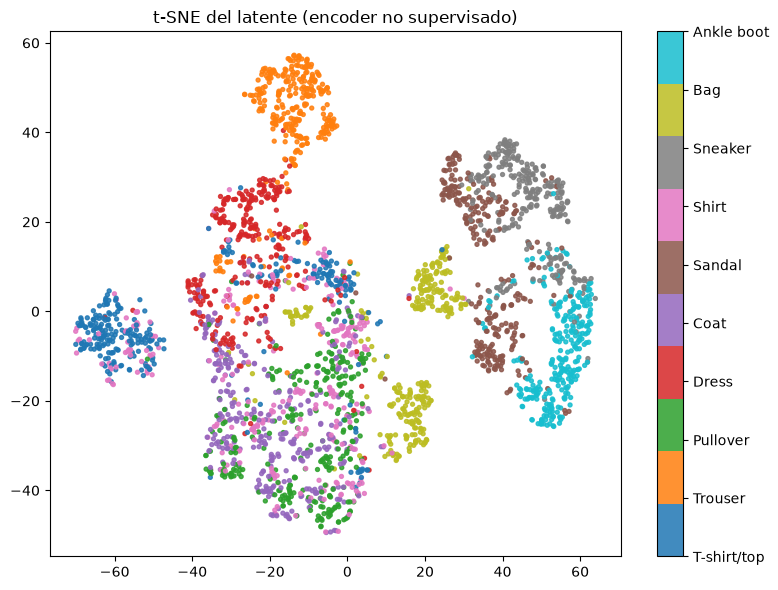

Si la sonda sobre z se acerca a la de píxeles, el AE organizó factores útiles (tipo de prenda) sin ver etiquetas. No sustituye a un clasificador entrenado desde cero, pero z es una representación compacta.


In [9]:
encoder_b = dense_models[64]["encoder"]
z_tr = encoder_b.predict(x_train, verbose=0)
z_te = encoder_b.predict(x_test, verbose=0)
print("z_train:", z_tr.shape)

clf_z = LogisticRegression(max_iter=200, random_state=SEED)
clf_z.fit(z_tr, y_train)
acc_z = clf_z.score(z_te, y_test)

n_sub = 10000
rng_sub = np.random.default_rng(SEED)
idx = rng_sub.choice(len(x_train), size=n_sub, replace=False)
clf_px = LogisticRegression(max_iter=200, random_state=SEED)
clf_px.fit(x_train[idx], y_train[idx])
acc_px = clf_px.score(x_test, y_test)

print(f"Exactitud test sobre z (64-D):     {acc_z:.3f}")
print(f"Exactitud test sobre píxeles (sub): {acc_px:.3f}")

z_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca").fit_transform(
    z_te[:3000]
)
plt.figure(figsize=(8, 6))
sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y_test[:3000], cmap="tab10", s=8, alpha=0.85)
cbar = plt.colorbar(sc, ticks=range(10))
cbar.ax.set_yticklabels(FASHION_NAMES)
plt.title("t-SNE del latente (encoder no supervisado)")
plt.tight_layout()
plt.show()
print(
    "Si la sonda sobre z se acerca a la de píxeles, el AE organizó factores útiles "
    "(tipo de prenda) sin ver etiquetas. No sustituye a un clasificador entrenado "
    "desde cero, pero z es una representación compacta."
)


---

<a id="ejercicio-integrador"></a>
<h2 style="color: #007ACC;">Ejercicio integrador. Cáncer de mama</h2>


['malignant' 'benign'] | N= 569 | d= 30


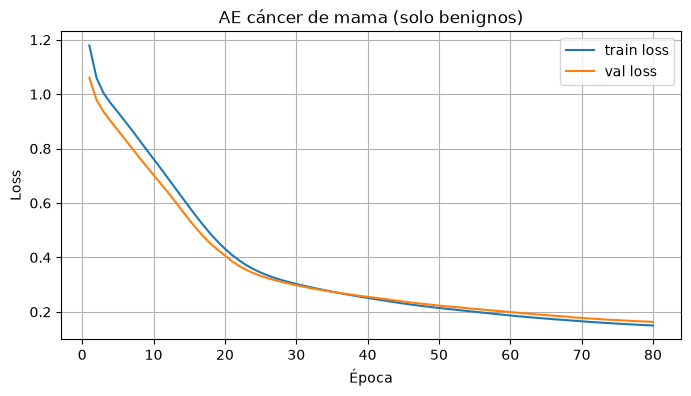

Umbral p95 val benigno: 0.4275
FPR benignos test: 5.6%
TPR malignos test: 79.2%
AUC AE: 0.956
AUC norma L2: 0.975
TPR norma L2: 71.7%


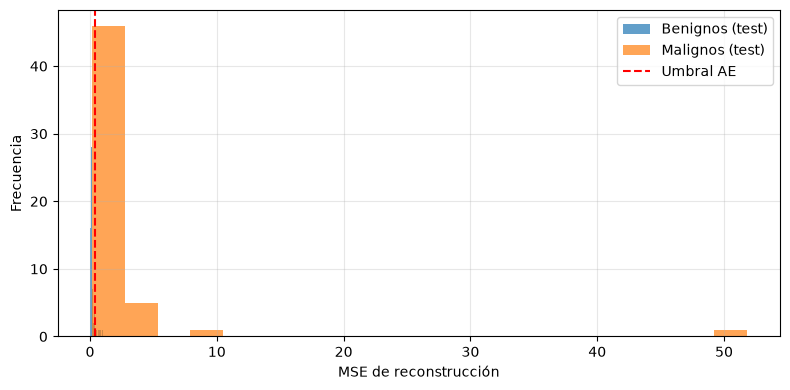

Conclusión: el AE se ajustó solo a benignos de train y el umbral salió del val benigno (sin leakage). En 30 features un AE pequeño a veces apenas supera a la norma L2: hay poca estructura no lineal que explotar y N es bajo. El valor del ejercicio es el pipeline (quién ve el scaler, quién entra al fit, de dónde sale el umbral), no batir un récord clínico.


In [10]:
data = load_breast_cancer()
X_bc, y_bc = data.data.astype("float32"), data.target.astype(int)
# 1 = benigno (normal), 0 = maligno (anomalía)
print(data.target_names, "| N=", len(y_bc), "| d=", X_bc.shape[1])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bc, y_bc, test_size=0.25, random_state=SEED, stratify=y_bc
)
X_n = X_tr[y_tr == 1]
X_n_fit, X_n_val = train_test_split(X_n, test_size=0.2, random_state=SEED)

scaler_bc = StandardScaler()
X_n_fit_s = scaler_bc.fit_transform(X_n_fit)
X_n_val_s = scaler_bc.transform(X_n_val)
X_te_s = scaler_bc.transform(X_te)

tf.random.set_seed(SEED)
ae_bc, _ = build_dense_ae(
    X_bc.shape[1], latent_dim=8, hidden=16, out_activation="linear"
)
hist_bc = ae_bc.fit(
    X_n_fit_s,
    X_n_fit_s,
    validation_data=(X_n_val_s, X_n_val_s),
    epochs=80,
    batch_size=16,
    callbacks=[EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=0,
)
plot_history(hist_bc, "AE cáncer de mama (solo benignos)")

thr_bc = np.percentile(
    reconstruction_mse(X_n_val_s, ae_bc.predict(X_n_val_s, verbose=0)), 95
)
err_te = reconstruction_mse(X_te_s, ae_bc.predict(X_te_s, verbose=0))
pred = err_te > thr_bc
y_mal = (y_te == 0).astype(int)
print(f"Umbral p95 val benigno: {thr_bc:.4f}")
print(f"FPR benignos test: {pred[y_te == 1].mean():.1%}")
print(f"TPR malignos test: {pred[y_te == 0].mean():.1%}")
print(f"AUC AE: {roc_auc_score(y_mal, err_te):.3f}")

# Baseline: norma L2 del vector (sin AE)
norm_val = np.linalg.norm(X_n_val_s, axis=1)
thr_norm = np.percentile(norm_val, 95)
norm_te = np.linalg.norm(X_te_s, axis=1)
print(f"AUC norma L2: {roc_auc_score(y_mal, norm_te):.3f}")
print(f"TPR norma L2: {np.mean(norm_te[y_te == 0] > thr_norm):.1%}")

plt.figure(figsize=(8, 4))
plt.hist(err_te[y_te == 1], bins=20, alpha=0.7, label="Benignos (test)")
plt.hist(err_te[y_te == 0], bins=20, alpha=0.7, label="Malignos (test)")
plt.axvline(thr_bc, color="red", linestyle="--", label="Umbral AE")
plt.xlabel("MSE de reconstrucción")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Conclusión: el AE se ajustó solo a benignos de train y el umbral salió del val "
    "benigno (sin leakage). En 30 features un AE pequeño a veces apenas supera a la "
    "norma L2: hay poca estructura no lineal que explotar y N es bajo. El valor del "
    "ejercicio es el pipeline (quién ve el scaler, quién entra al fit, de dónde sale "
    "el umbral), no batir un récord clínico."
)
